# Microgrid siting: Ntabankulu

This notebook selects microgrid sites in one ward of Ntabankulu Local Municipality (EC444).
`ward_choice.ipynb` selects the ward.

Steps:
1. Load the buildings and the grid.
2. Find the settlements that are far from the grid.
3. Select the candidate sites. Each candidate site is one qubit.
4. Write the siting problem as a QUBO.
5. Solve the QUBO with QAOA, on a simulator and on IBM hardware.

The exact classical solution is the reference for all results.

To change the problem, edit the config in the next cell, then run all cells. The first run
downloads the Overture buildings for the municipality (approximately 3 minutes). Later runs
use the local cache.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np

from quackathon.classical import solve_exact, solve_qubo_brute_force
from quackathon.config import PilotConfig
from quackathon.grid import load_grid
from quackathon.overture import fetch_building_centroids
from quackathon.pipeline import build_pilot
from quackathon.quantum import dicke_state, qaoa_circuit, qaoa_depth_sweep, qubo_to_ising
from quackathon.region import load_wards
from quackathon import viz

viz.use_style()
%config InlineBackend.figure_format = "retina"

In [2]:
cfg = PilotConfig(
    ward_no=4,               # selected in ward_choice.ipynb
    grid_distance_m=2_000,   # demand: settlements beyond this distance from the grid
    n_sites=3,               # microgrids to build
    n_candidates=12,         # candidate sites = qubits
    service_radius_m=1_500,  # reach of a microgrid's distribution network
    grid_source="gridfinder",  # OSM + predicted MV grid; "osm" = mapped lines only
)
pilot = build_pilot(cfg)
p = pilot.problem
print(f"{len(pilot.buildings):,} buildings -> {len(pilot.all_nodes)} demand nodes, "
      f"{len(pilot.nodes)} beyond {cfg.grid_distance_m:,.0f} m of grid ({p.demand.sum():.0f} kWh/day)")
print(f"{p.n_sites} candidate sites (qubits), choose {p.n_select}")

5,781 buildings -> 111 demand nodes, 86 beyond 2,000 m of grid (574 kWh/day)
12 candidate sites (qubits), choose 3


## 1. The municipality

Colour shows the number of buildings in each ward (Overture: Google, Microsoft and OSM
footprints). Solid lines are grid lines from OSM. Dashed lines are the medium-voltage grid
that gridfinder predicts (Arderne et al. 2020). Gridfinder uses night-time lights and roads,
so the dashed lines are an estimate.

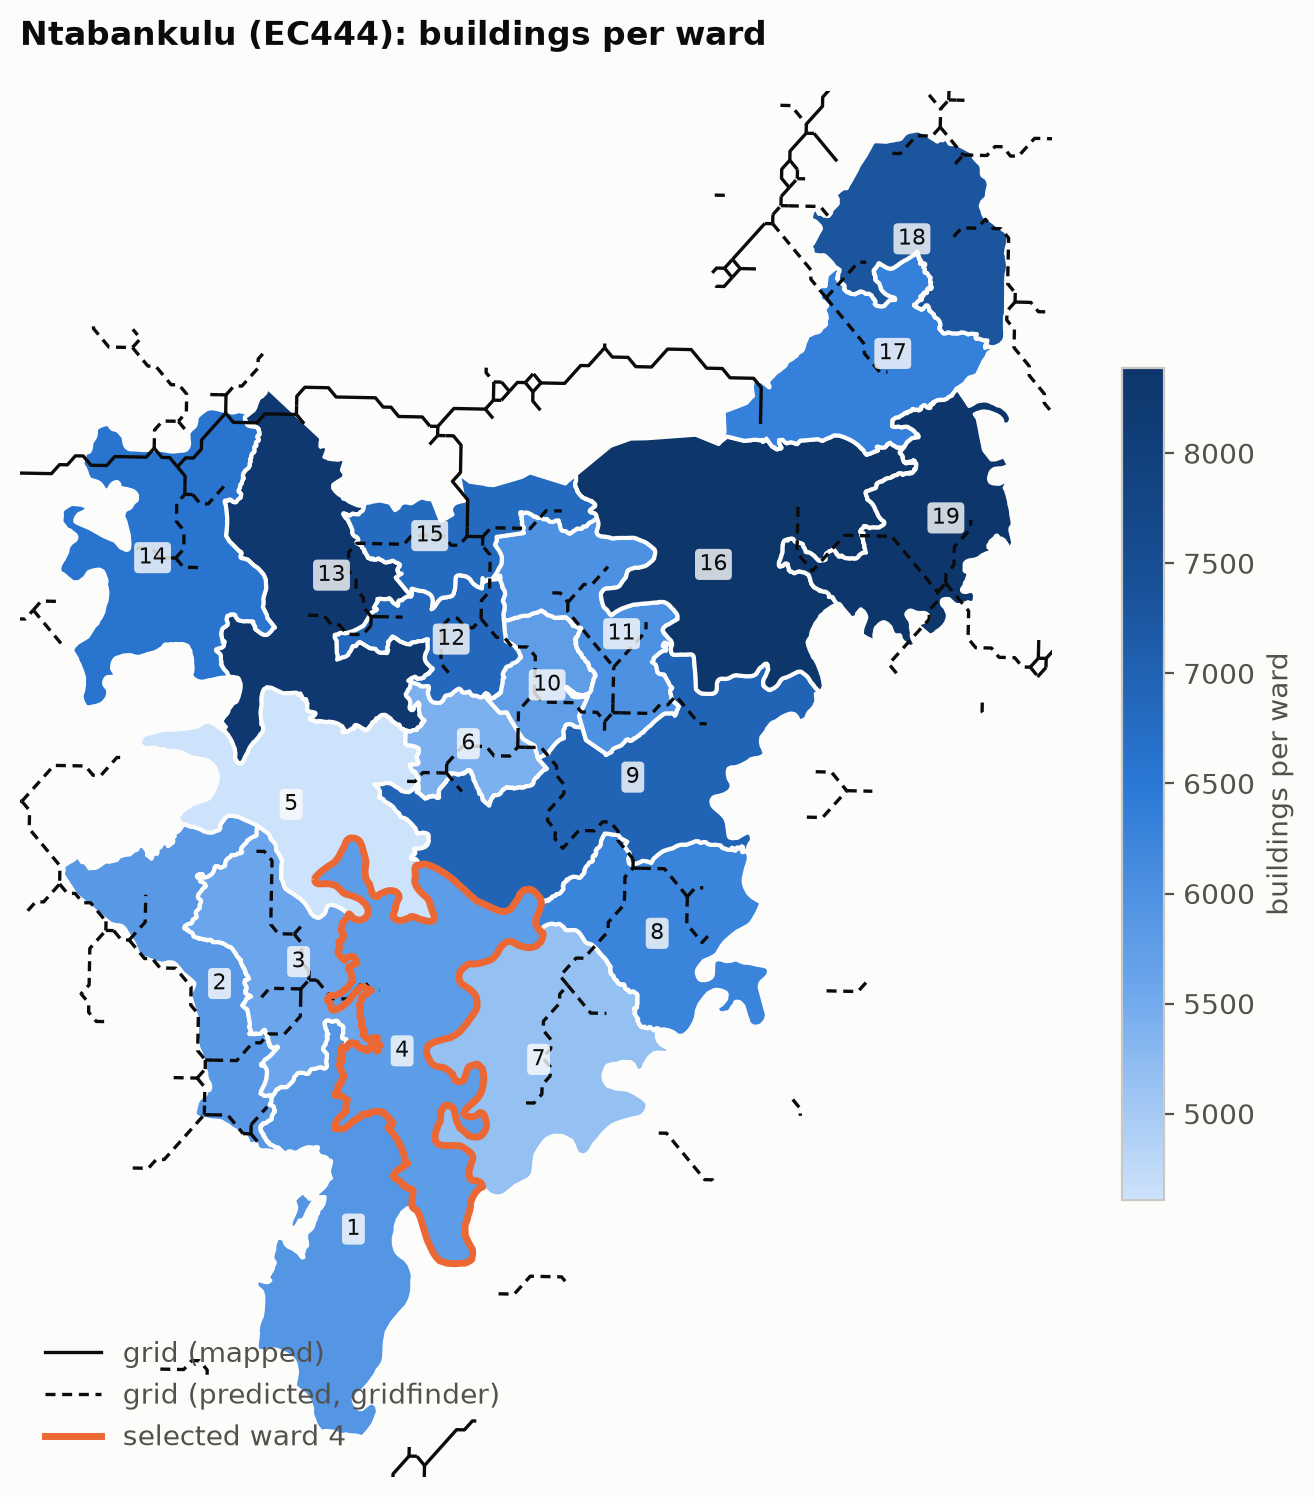

In [3]:
wards = load_wards(cfg)
all_buildings = fetch_building_centroids(wards, cfg.raw_dir)
municipal_grid = load_grid(wards, cfg)
viz.plot_municipality(wards, all_buildings, municipal_grid, pilot_ward=cfg.ward_no)
plt.show()

## 2. Settlements far from the grid

`grid_distance_m` divides the buildings in the ward into two groups:
- Buildings within this distance can connect to the grid. They are not in the problem.
- Buildings beyond this distance are microgrid demand.

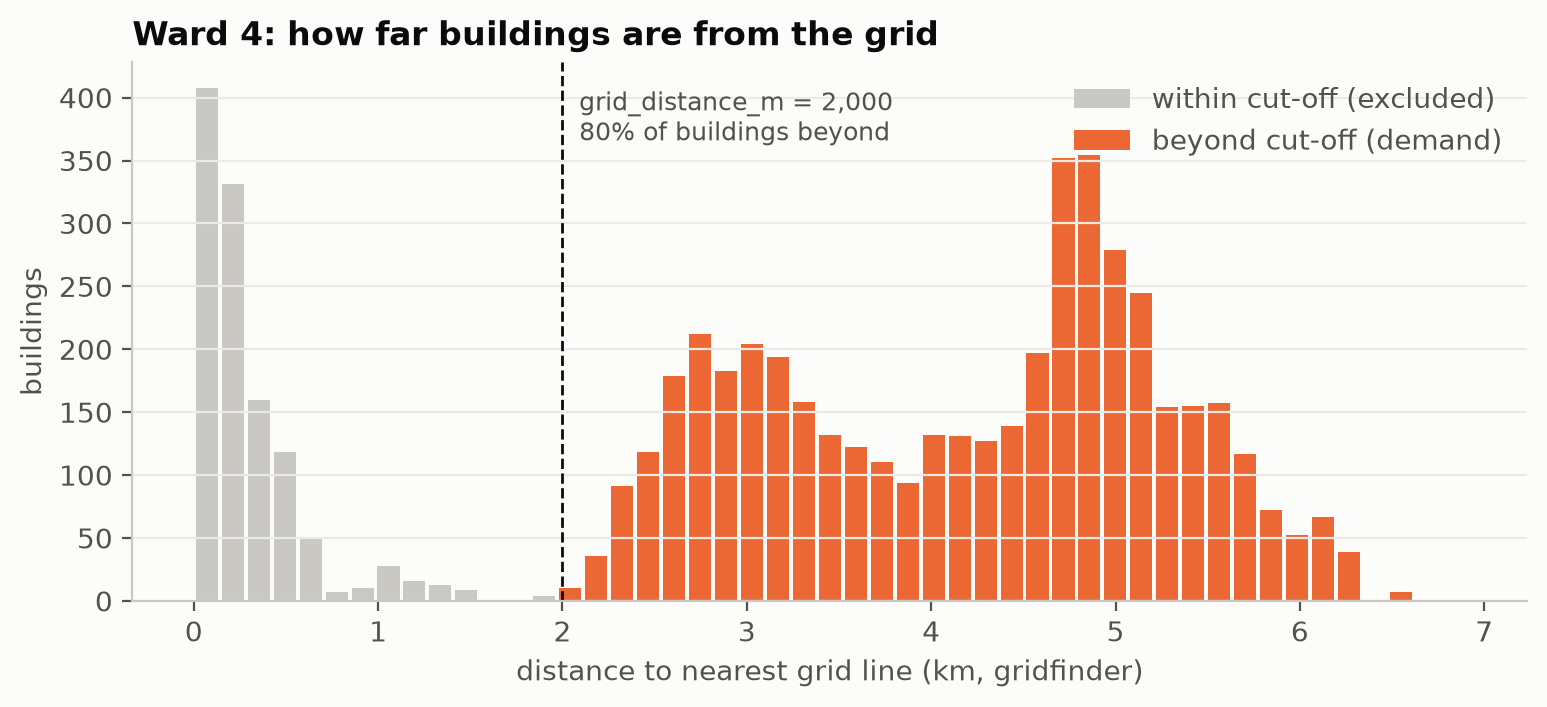

In [4]:
viz.plot_grid_distance(pilot)
plt.show()

## 3. Candidate sites and the optimal selection

Grey dots are buildings. Coloured dots are demand nodes: 500 m cells beyond the cut-off,
sized by demand. Triangles are candidate sites, labelled with the qubit index. The right map
shows the exact optimum, from a search of all selections.

exact: x=100001000100  served=441.1 kWh/day
QUBO:  x=100001000100  served=441.1 kWh/day  feasible=True


/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)
/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


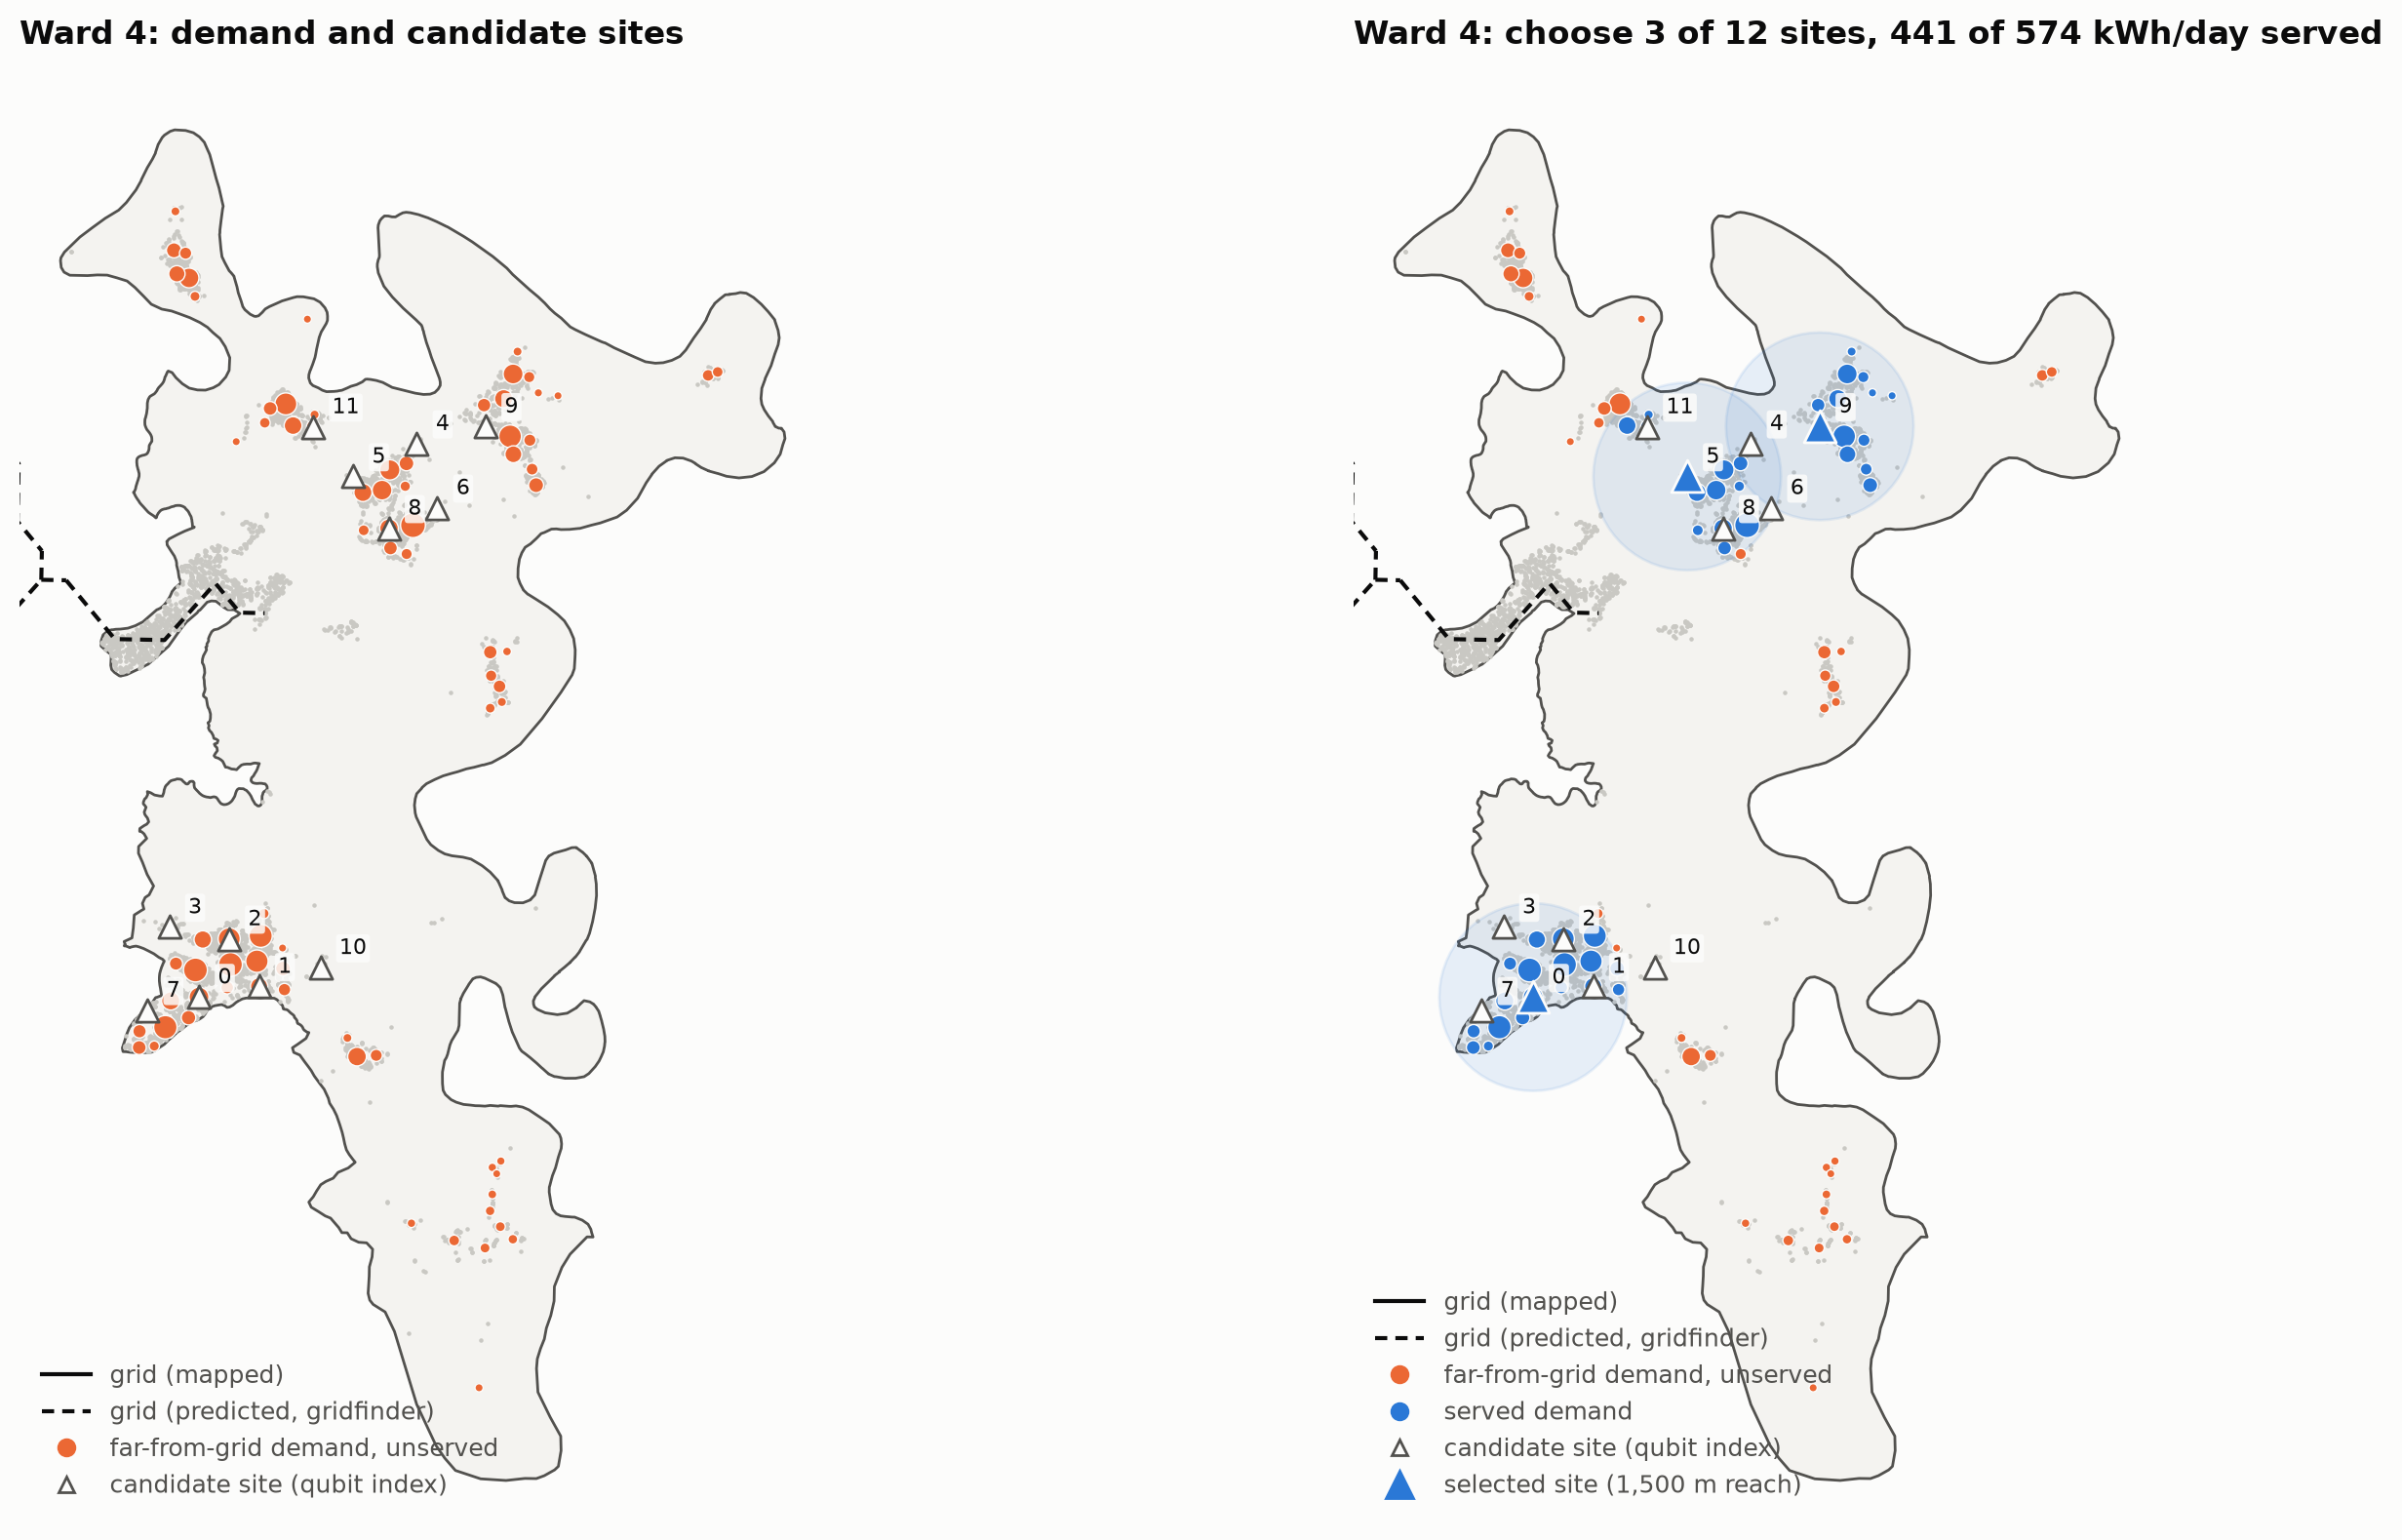

In [5]:
exact = solve_exact(p)
qubo = solve_qubo_brute_force(*p.to_qubo())
print(f"exact: x={''.join(map(str, exact.x))}  served={p.served_demand(exact.x):.1f} kWh/day")
print(f"QUBO:  x={''.join(map(str, qubo.x))}  served={p.served_demand(qubo.x):.1f} kWh/day  "
      f"feasible={p.is_feasible(qubo.x)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
viz.plot_pilot(pilot, ax=axes[0], title=f"Ward {cfg.ward_no}: demand and candidate sites")
viz.plot_pilot(pilot, exact.x, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. The QUBO

**Matrix.** The diagonal holds the demand that each site can reach, as a negative value, so
a selected site decreases the energy. The off-diagonal holds the demand that two sites both
reach, as a positive value. This term prevents the selection of two sites that serve the same
demand. The cardinality penalty adds `P(1−2K)` to each diagonal entry and `2P` to each
off-diagonal entry. The plot excludes the penalty. To include it, set `include_penalty=True`.

penalty P = 226.5


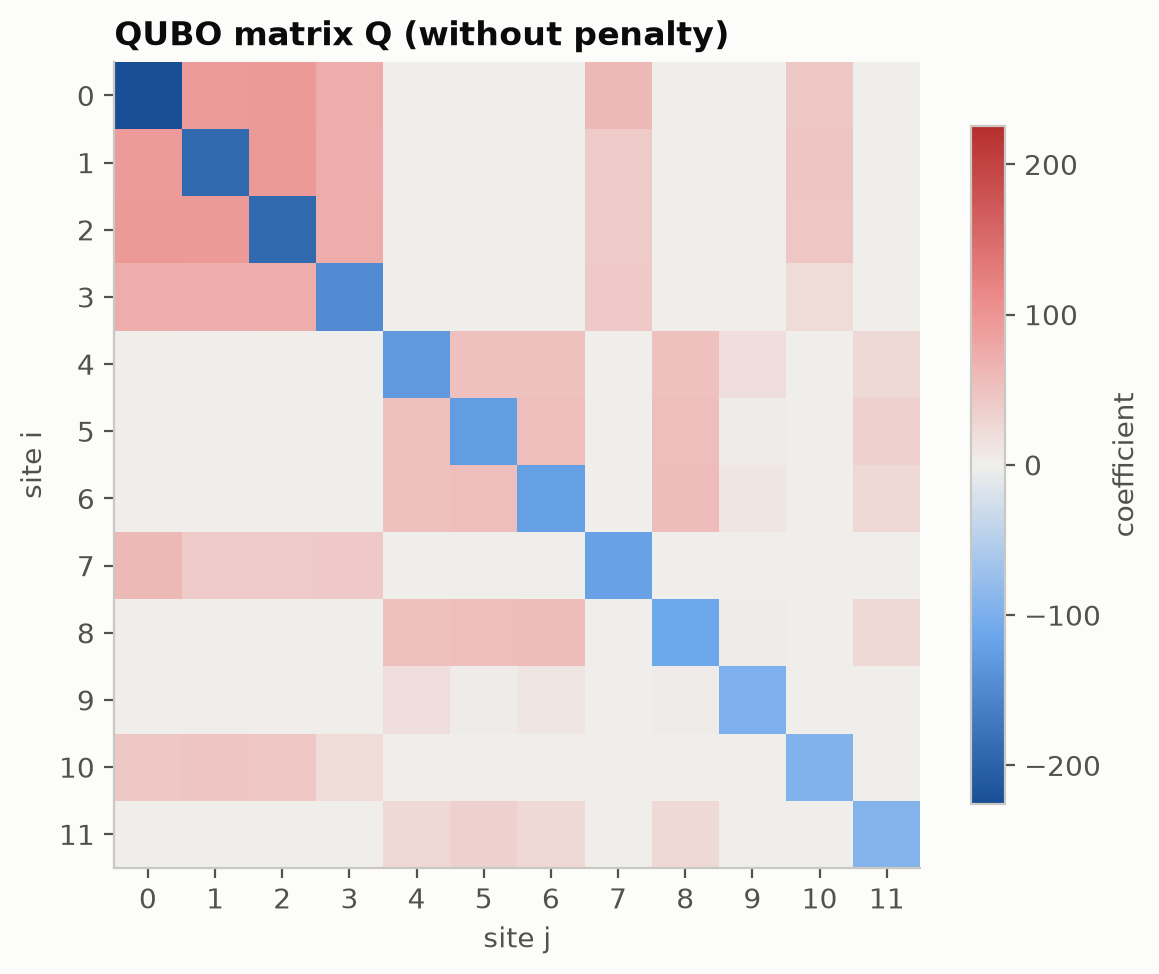

In [6]:
print(f"penalty P = {p.to_qubo()[1] / p.n_select**2:.1f}")
viz.plot_qubo_matrix(p)
plt.show()

**Energy landscape.** All 2ⁿ bitstrings, ranked by QUBO energy. A good QAOA result puts most
of the probability on the leftmost state. The penalty must put each infeasible state
(incorrect number of sites) above the best feasible states.

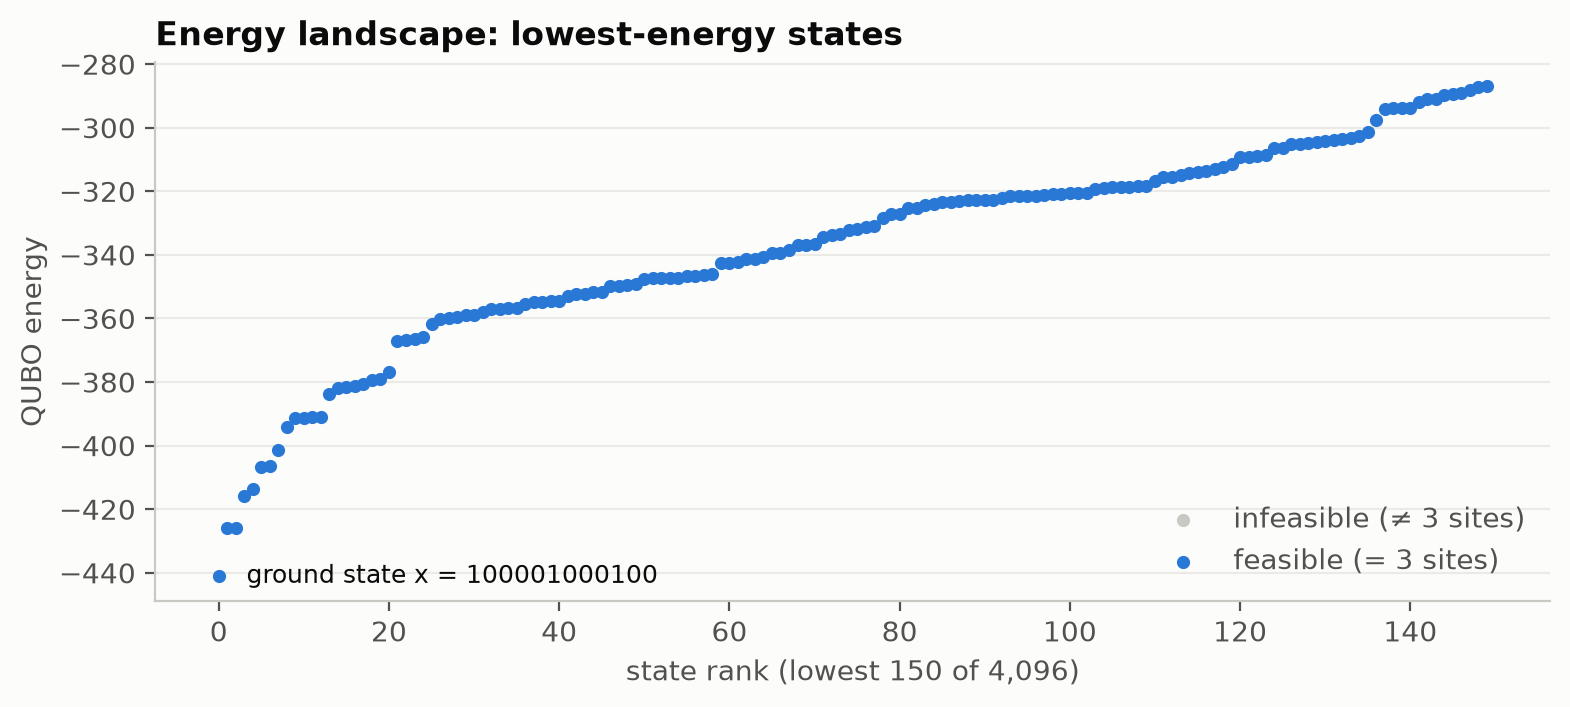

In [7]:
viz.plot_energy_landscape(p, n_lowest=150)
plt.show()

**Approximation quality.** The QUBO counts coverage only to pairwise overlaps. Each dot is
one feasible selection. Dots on the diagonal are exact. Dots below the diagonal subtract
overlap too many times. This occurs when three or more selected sites cover one demand node.

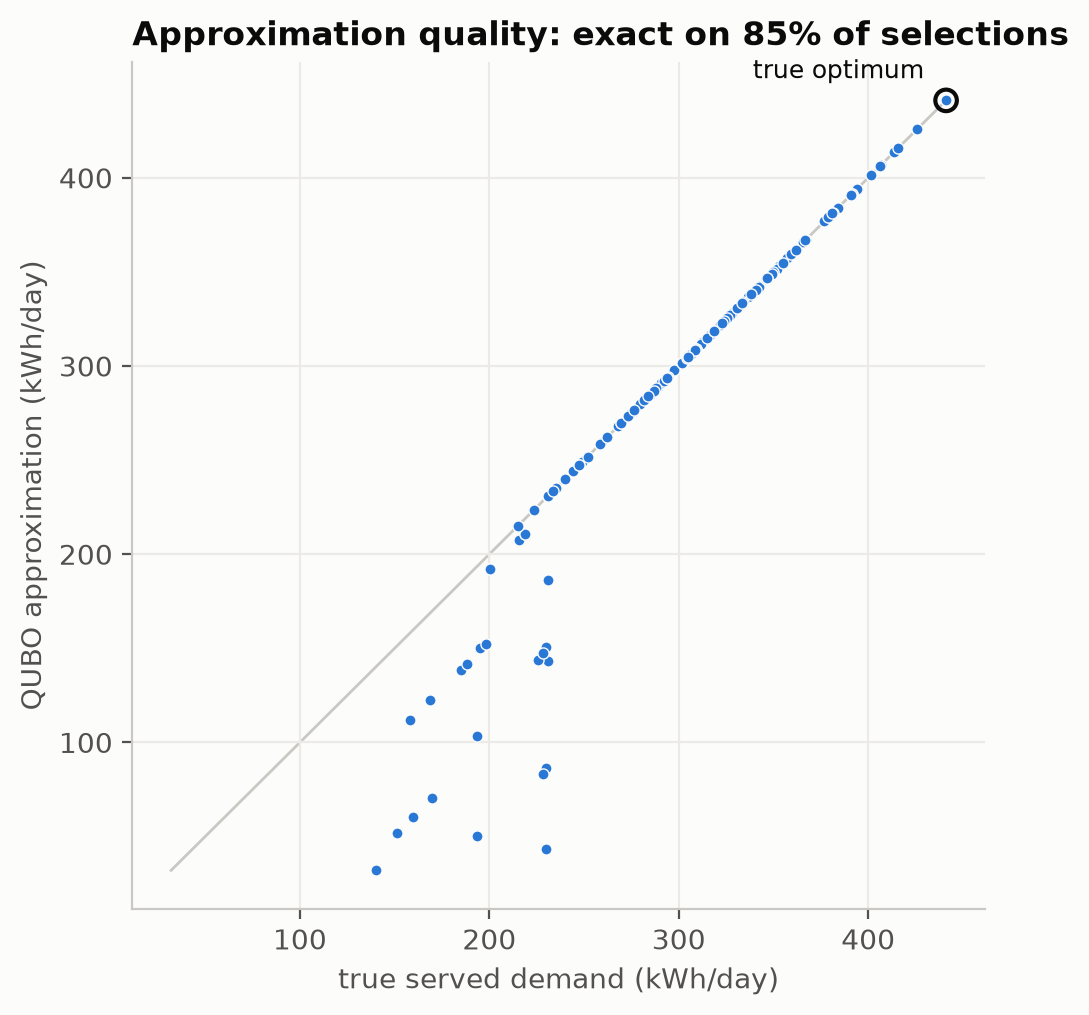

In [8]:
viz.plot_qubo_vs_exact(p)
plt.show()

## 5. Sensitivity to the config

The share of far-from-grid demand that the best selection serves, as the number of sites and
the service radius change. If the two lines separate, the QUBO optimum is different from the
exact optimum.

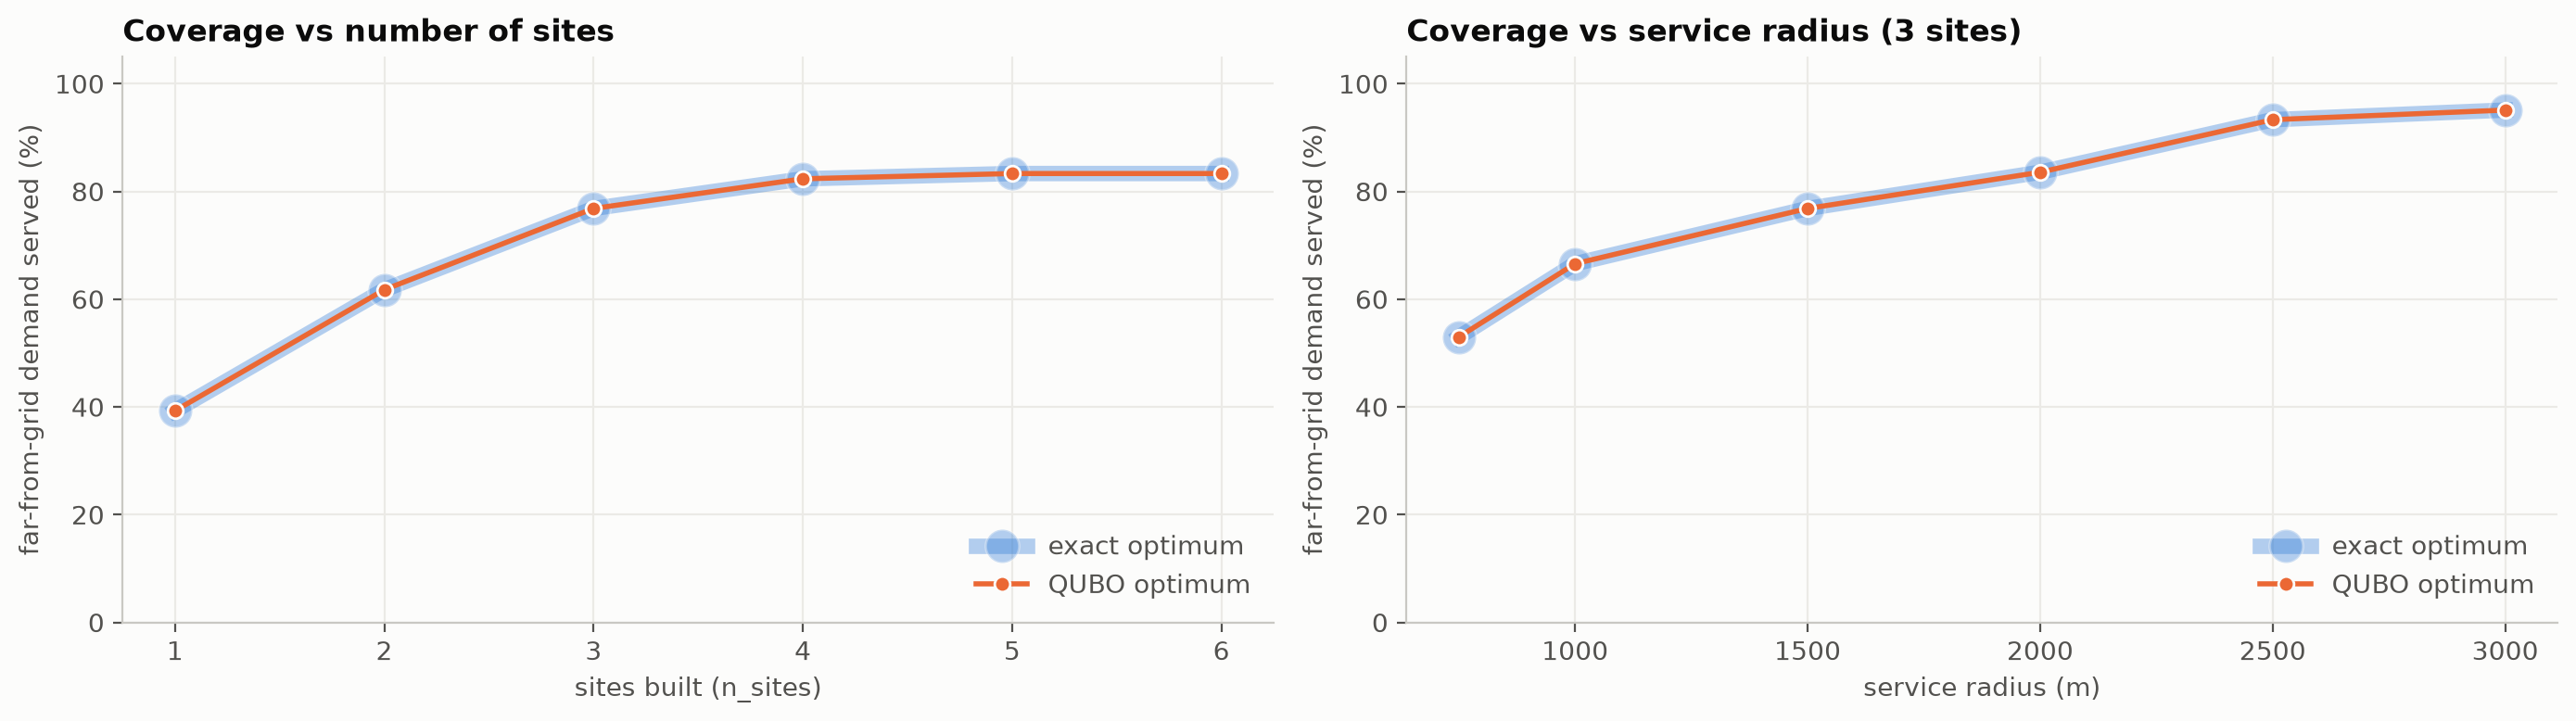

In [9]:
def served_by_both(problem):
    ex = solve_exact(problem)
    qb = solve_qubo_brute_force(*problem.to_qubo())
    return problem.served_demand(ex.x), problem.served_demand(qb.x)

ks = list(range(1, 7))
by_k = np.array([served_by_both(replace(p, n_select=k)) for k in ks])

radii = [750, 1_000, 1_500, 2_000, 2_500, 3_000]
by_r, total_r = [], []
for r in radii:
    pr = build_pilot(replace(cfg, service_radius_m=r)).problem
    by_r.append(served_by_both(pr))
    total_r.append(pr.demand.sum())
by_r = np.array(by_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
viz.plot_sweep(ks, {"exact optimum": by_k[:, 0], "QUBO optimum": by_k[:, 1]}, p.demand.sum(),
               "sites built (n_sites)", "Coverage vs number of sites", ax=axes[0])
viz.plot_sweep(radii, {"exact optimum": by_r[:, 0], "QUBO optimum": by_r[:, 1]}, total_r,
               "service radius (m)", f"Coverage vs service radius ({cfg.n_sites} sites)", ax=axes[1])
plt.tight_layout()
plt.show()

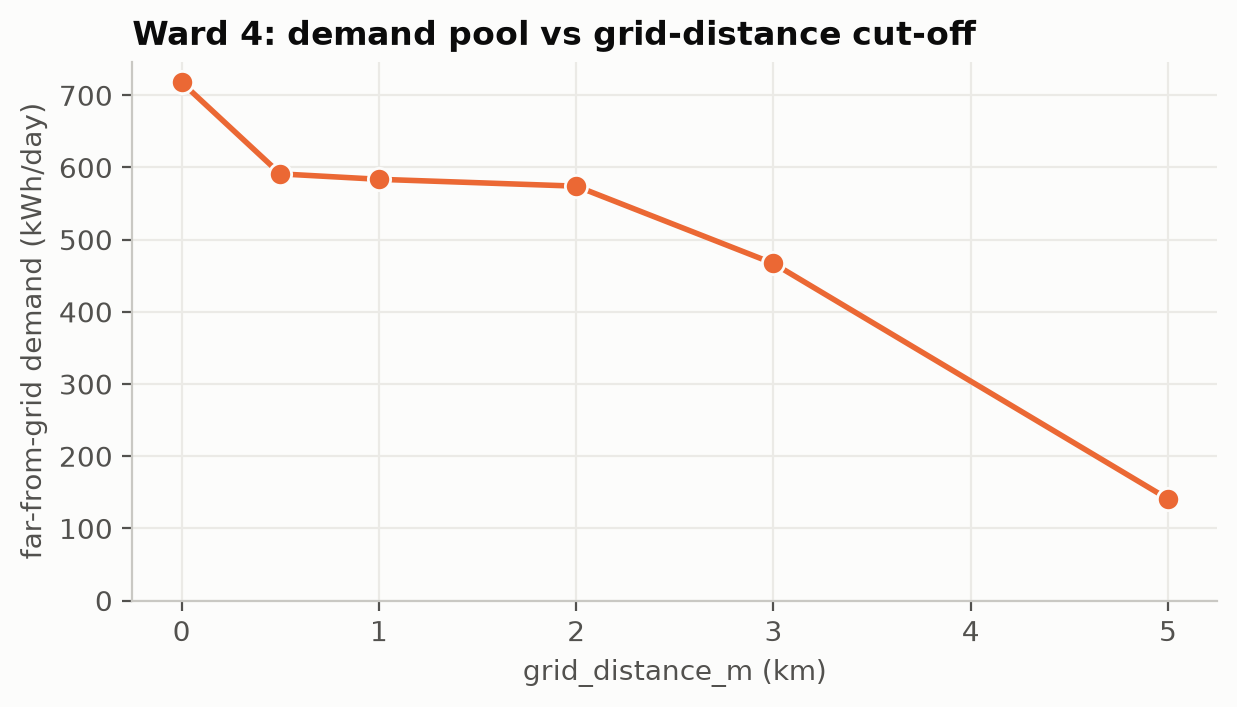

In [10]:
# How the demand pool shrinks as the grid-distance cut-off grows.
distances = [0, 500, 1_000, 2_000, 3_000, 5_000]
pool = []
for d in distances:
    try:
        pool.append(build_pilot(replace(cfg, grid_distance_m=d)).problem.demand.sum())
    except ValueError:  # fewer demand nodes than candidate sites
        pool.append(np.nan)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.array(distances) / 1000, pool, color=viz.UNSERVED, marker="o", markersize=8,
        markeredgecolor=viz.SURFACE)
ax.set_xlabel("grid_distance_m (km)")
ax.set_ylabel("far-from-grid demand (kWh/day)")
ax.set_ylim(bottom=0)
ax.set_title(f"Ward {cfg.ward_no}: demand pool vs grid-distance cut-off")
plt.show()

## 6. QAOA on a simulator

The QUBO becomes an Ising Hamiltonian through `x_j = (1 − Z_j)/2`. Each candidate site is
one qubit. QAOA alternates the cost Hamiltonian and a mixer. COBYLA tunes the angles against
Qiskit's `StatevectorEstimator`. `StatevectorSampler` then samples the tuned circuit.

Two mixers:
- **XY mixer (default):** The circuit starts in the Dicke state, an equal superposition of
  all selections with exactly K sites. The mixer swaps neighbouring qubits. Each measurement
  is a valid K-site plan, so the penalty is not necessary.
- **X mixer:** Standard QAOA from `|+⟩ⁿ`. The QUBO penalty enforces K.

The optimum at depth p−1 sets the start angles at depth p (INTERP). Thus a full sweep costs
approximately the same as one run at the maximum depth. At 12 qubits, depth 4 takes
approximately 25 s for each mixer.

In [11]:
MAX_REPS = 4
sweeps = {mixer: qaoa_depth_sweep(p, MAX_REPS, mixer=mixer) for mixer in ("xy", "x")}
best = sweeps["xy"][-1]
print(f"QAOA (xy, p={best.reps}): x={''.join(map(str, best.x))}  served={p.served_demand(best.x):.1f} kWh/day "
      f"(exact optimum {p.served_demand(exact.x):.1f})")
for mixer, results in sweeps.items():
    for r in results:
        print(f"  {mixer:2s} p={r.reps}: P(opt)={r.p_ground:.3f} ({r.p_ground / r.p_ground_random:.1f}﷿﷿ random)  "
              f"P(feasible)={r.p_feasible:.2f}  approx ratio={r.approximation_ratio:.2f}")

QAOA (xy, p=4): x=100001000100  served=441.1 kWh/day (exact optimum 441.1)
  xy p=1: P(opt)=0.016 (3.5﷿﷿ random)  P(feasible)=1.00  approx ratio=0.74
  xy p=2: P(opt)=0.035 (7.7﷿﷿ random)  P(feasible)=1.00  approx ratio=0.78
  xy p=3: P(opt)=0.078 (17.1﷿﷿ random)  P(feasible)=1.00  approx ratio=0.80
  xy p=4: P(opt)=0.142 (31.3﷿﷿ random)  P(feasible)=1.00  approx ratio=0.82
  x  p=1: P(opt)=0.000 (0.3﷿﷿ random)  P(feasible)=0.02  approx ratio=-5.81
  x  p=2: P(opt)=0.002 (7.1﷿﷿ random)  P(feasible)=0.27  approx ratio=-2.07
  x  p=3: P(opt)=0.002 (9.2﷿﷿ random)  P(feasible)=0.31  approx ratio=-2.03
  x  p=4: P(opt)=0.004 (16.0﷿﷿ random)  P(feasible)=0.22  approx ratio=-2.26


**The circuit.** Depth 1 with the XY mixer: Dicke-state preparation, the cost layer (RZ and
RZZ rotations), then XY swaps around the ring.

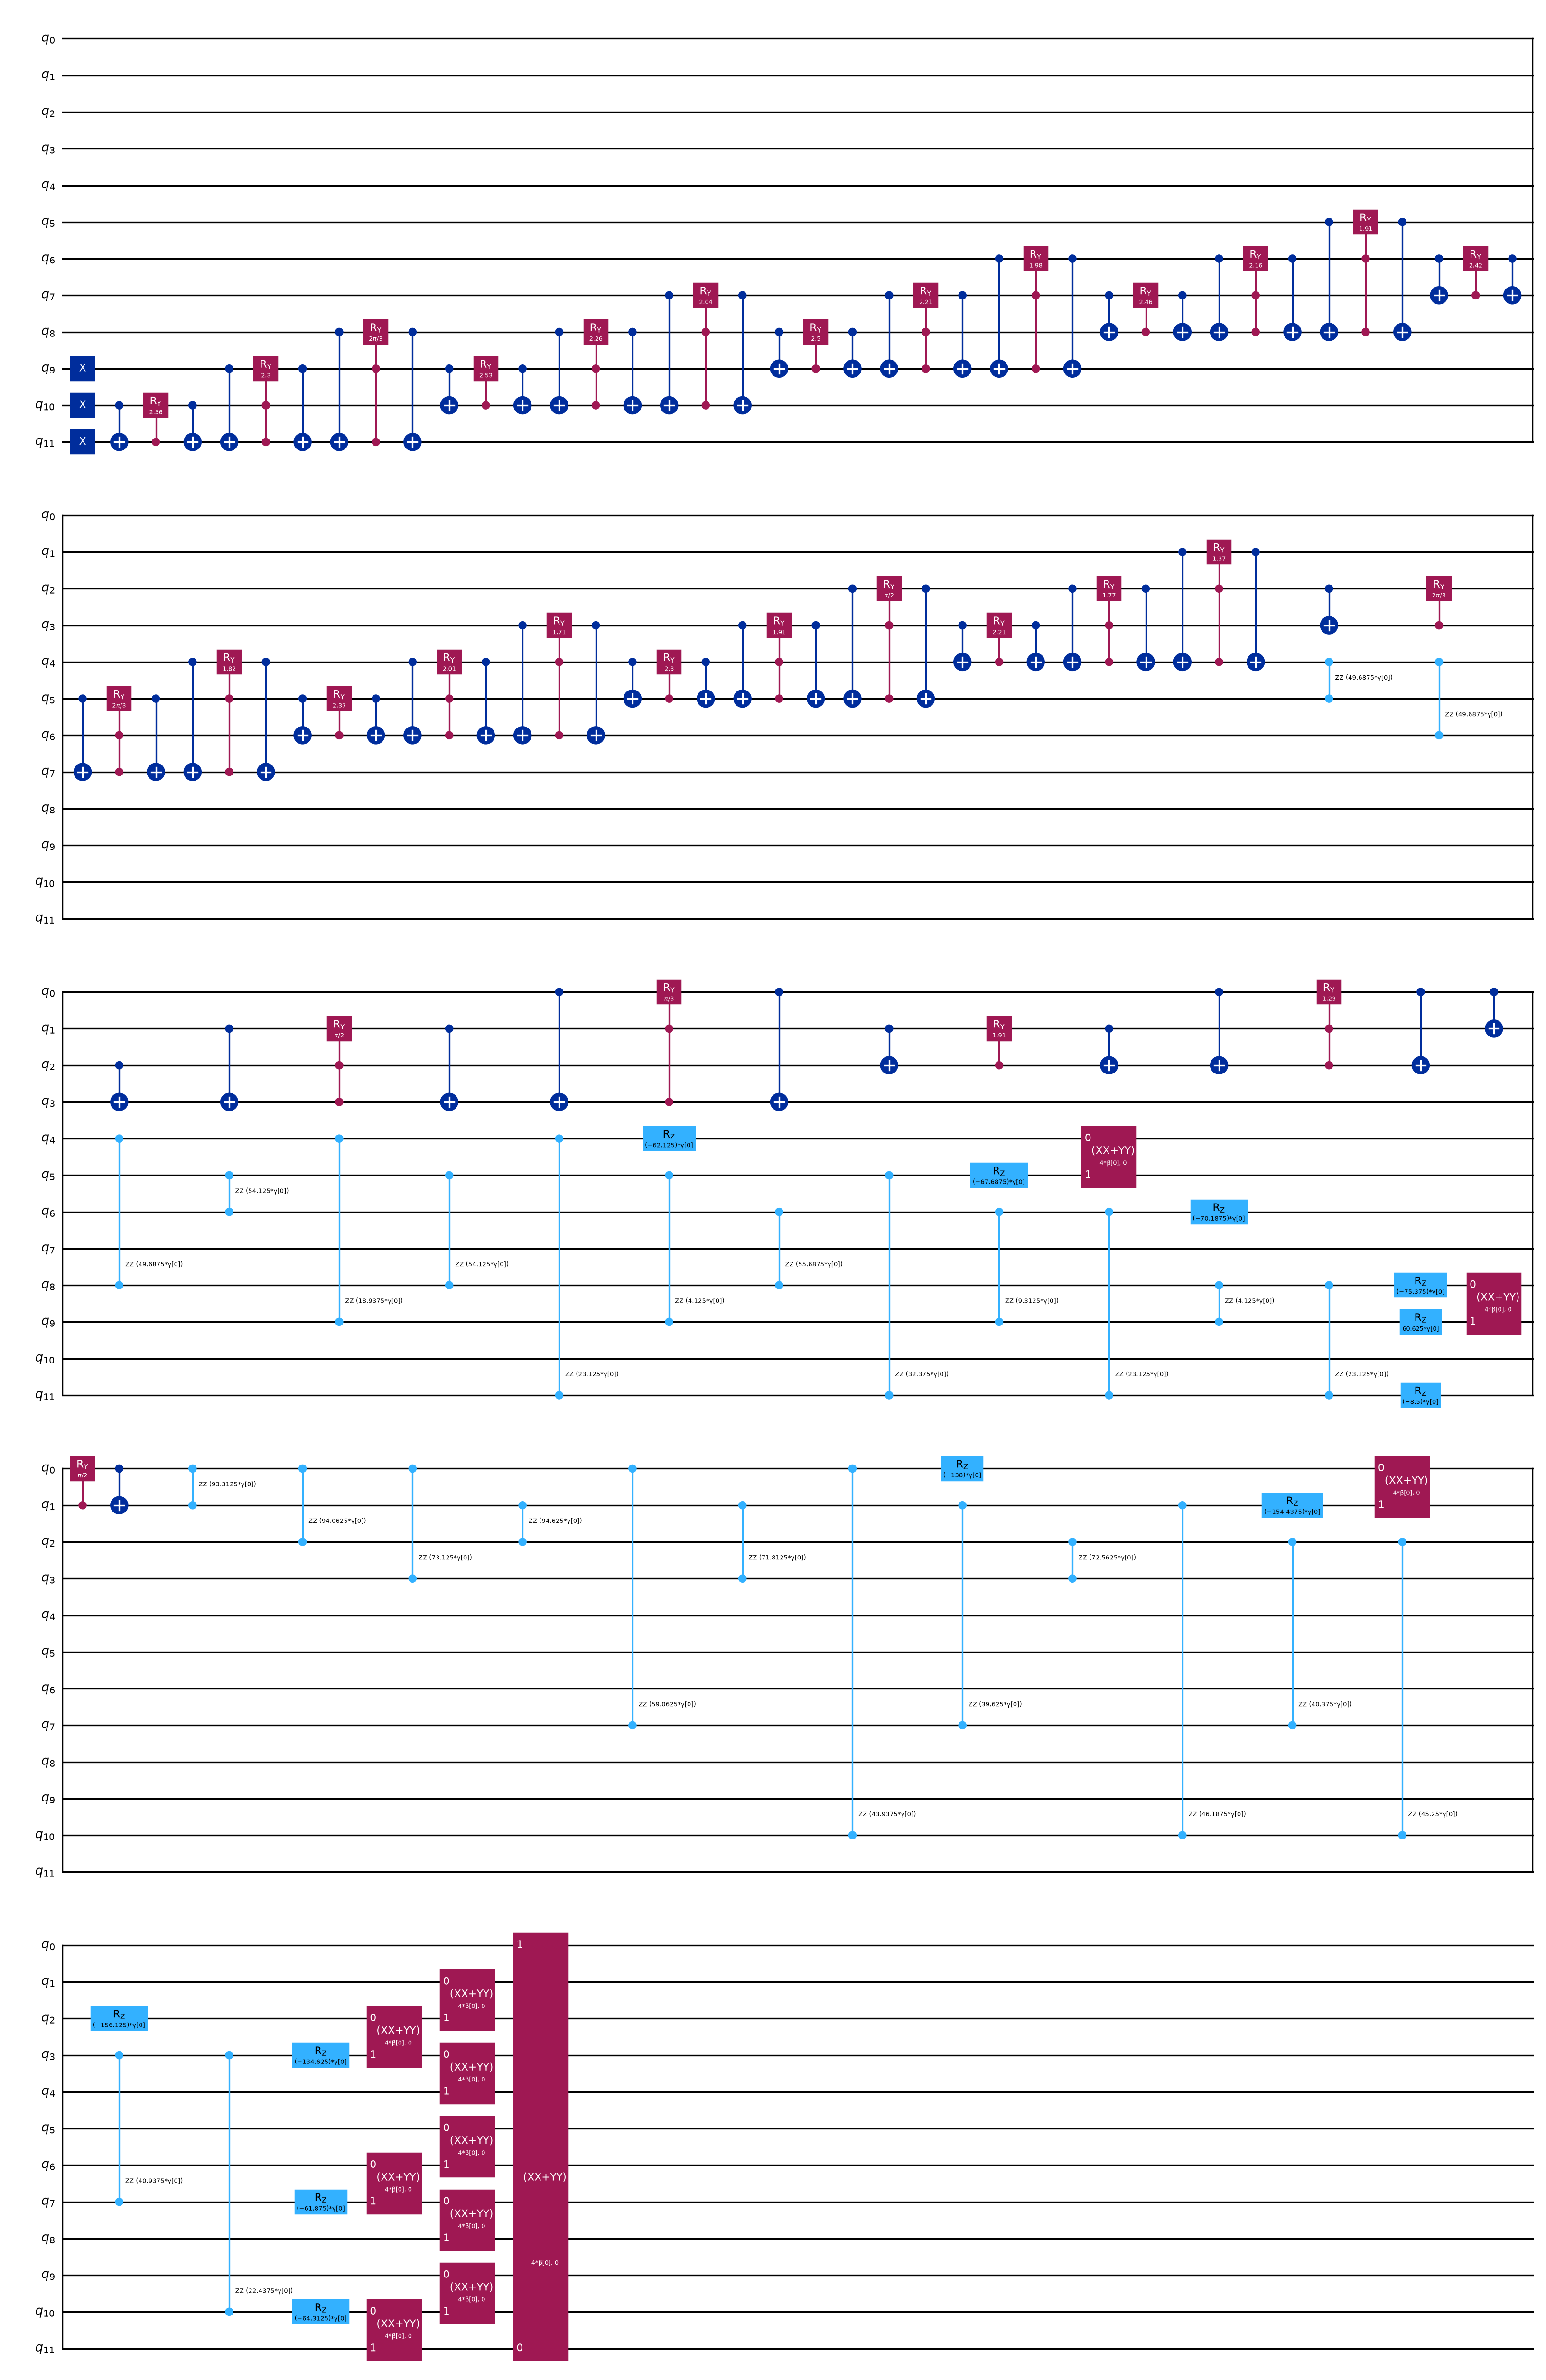

In [12]:
h, _ = qubo_to_ising(*p.to_qubo(0.0))
qaoa_circuit(h, reps=1, mixer="xy", n_select=p.n_select).draw("mpl", fold=40, scale=0.6)

**Probability distribution.** Feasible selections, ranked from best to worst energy. Bars
above the dashed line occur more frequently than in a random selection.

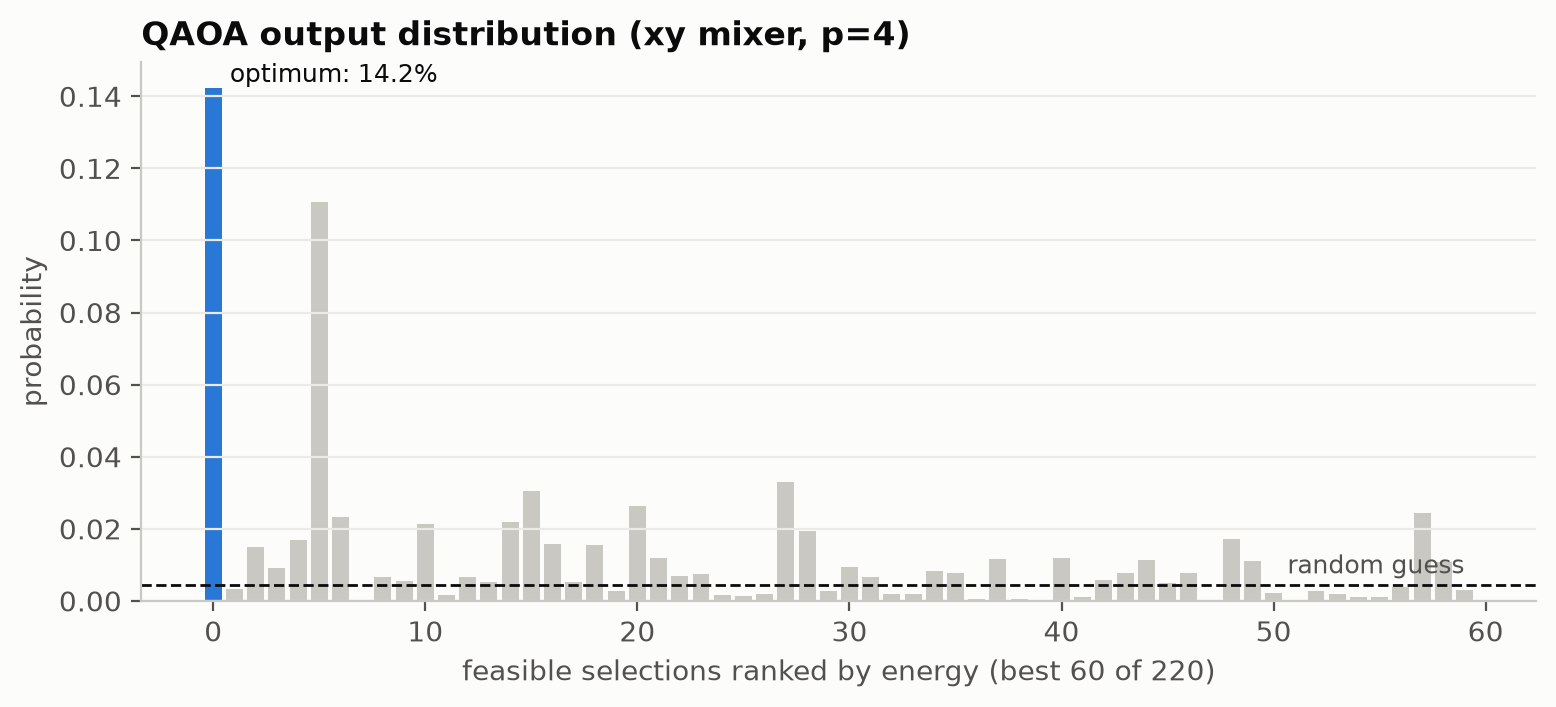

In [13]:
viz.plot_qaoa_distribution(best)
plt.show()

**Depth and mixer.** P(optimum) against the random baseline of each mixer (dashed): 1/2ⁿ for
the X mixer and 1/C(n, K) for the XY mixer. The approximation ratio is 1 when the expected
energy is equal to the optimum, and 0 when it is equal to the worst feasible plan. A value
below 0 shows probability on infeasible states.

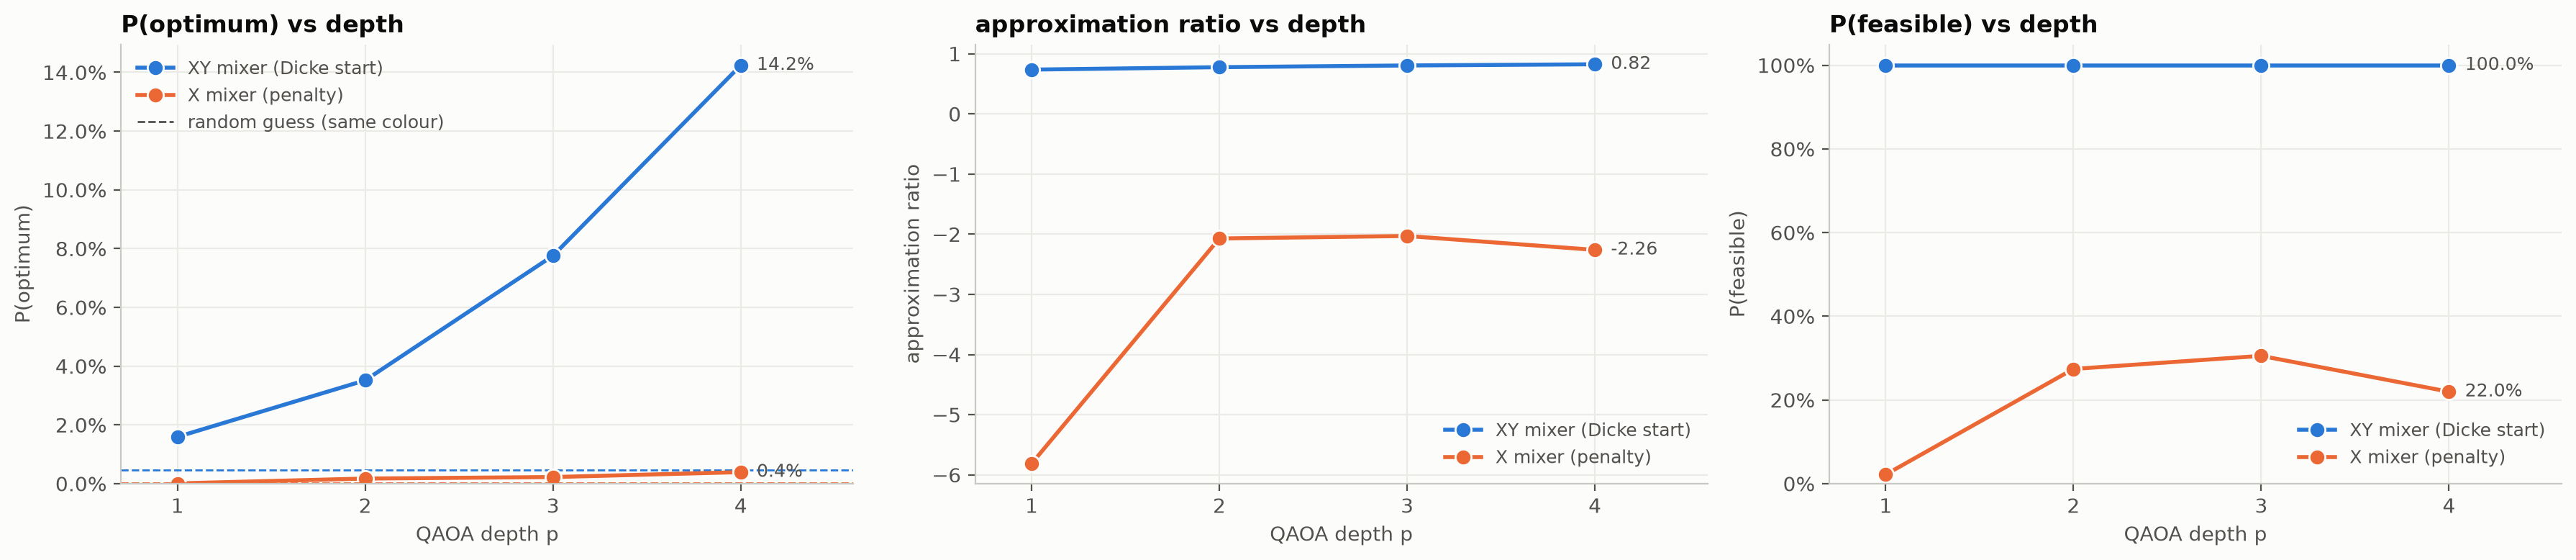

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
viz.plot_depth_sweep(sweeps, "p_ground", ax=axes[0])
viz.plot_depth_sweep(sweeps, "approximation_ratio", ax=axes[1])
viz.plot_depth_sweep(sweeps, "p_feasible", ax=axes[2])
plt.tight_layout()
plt.show()

/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


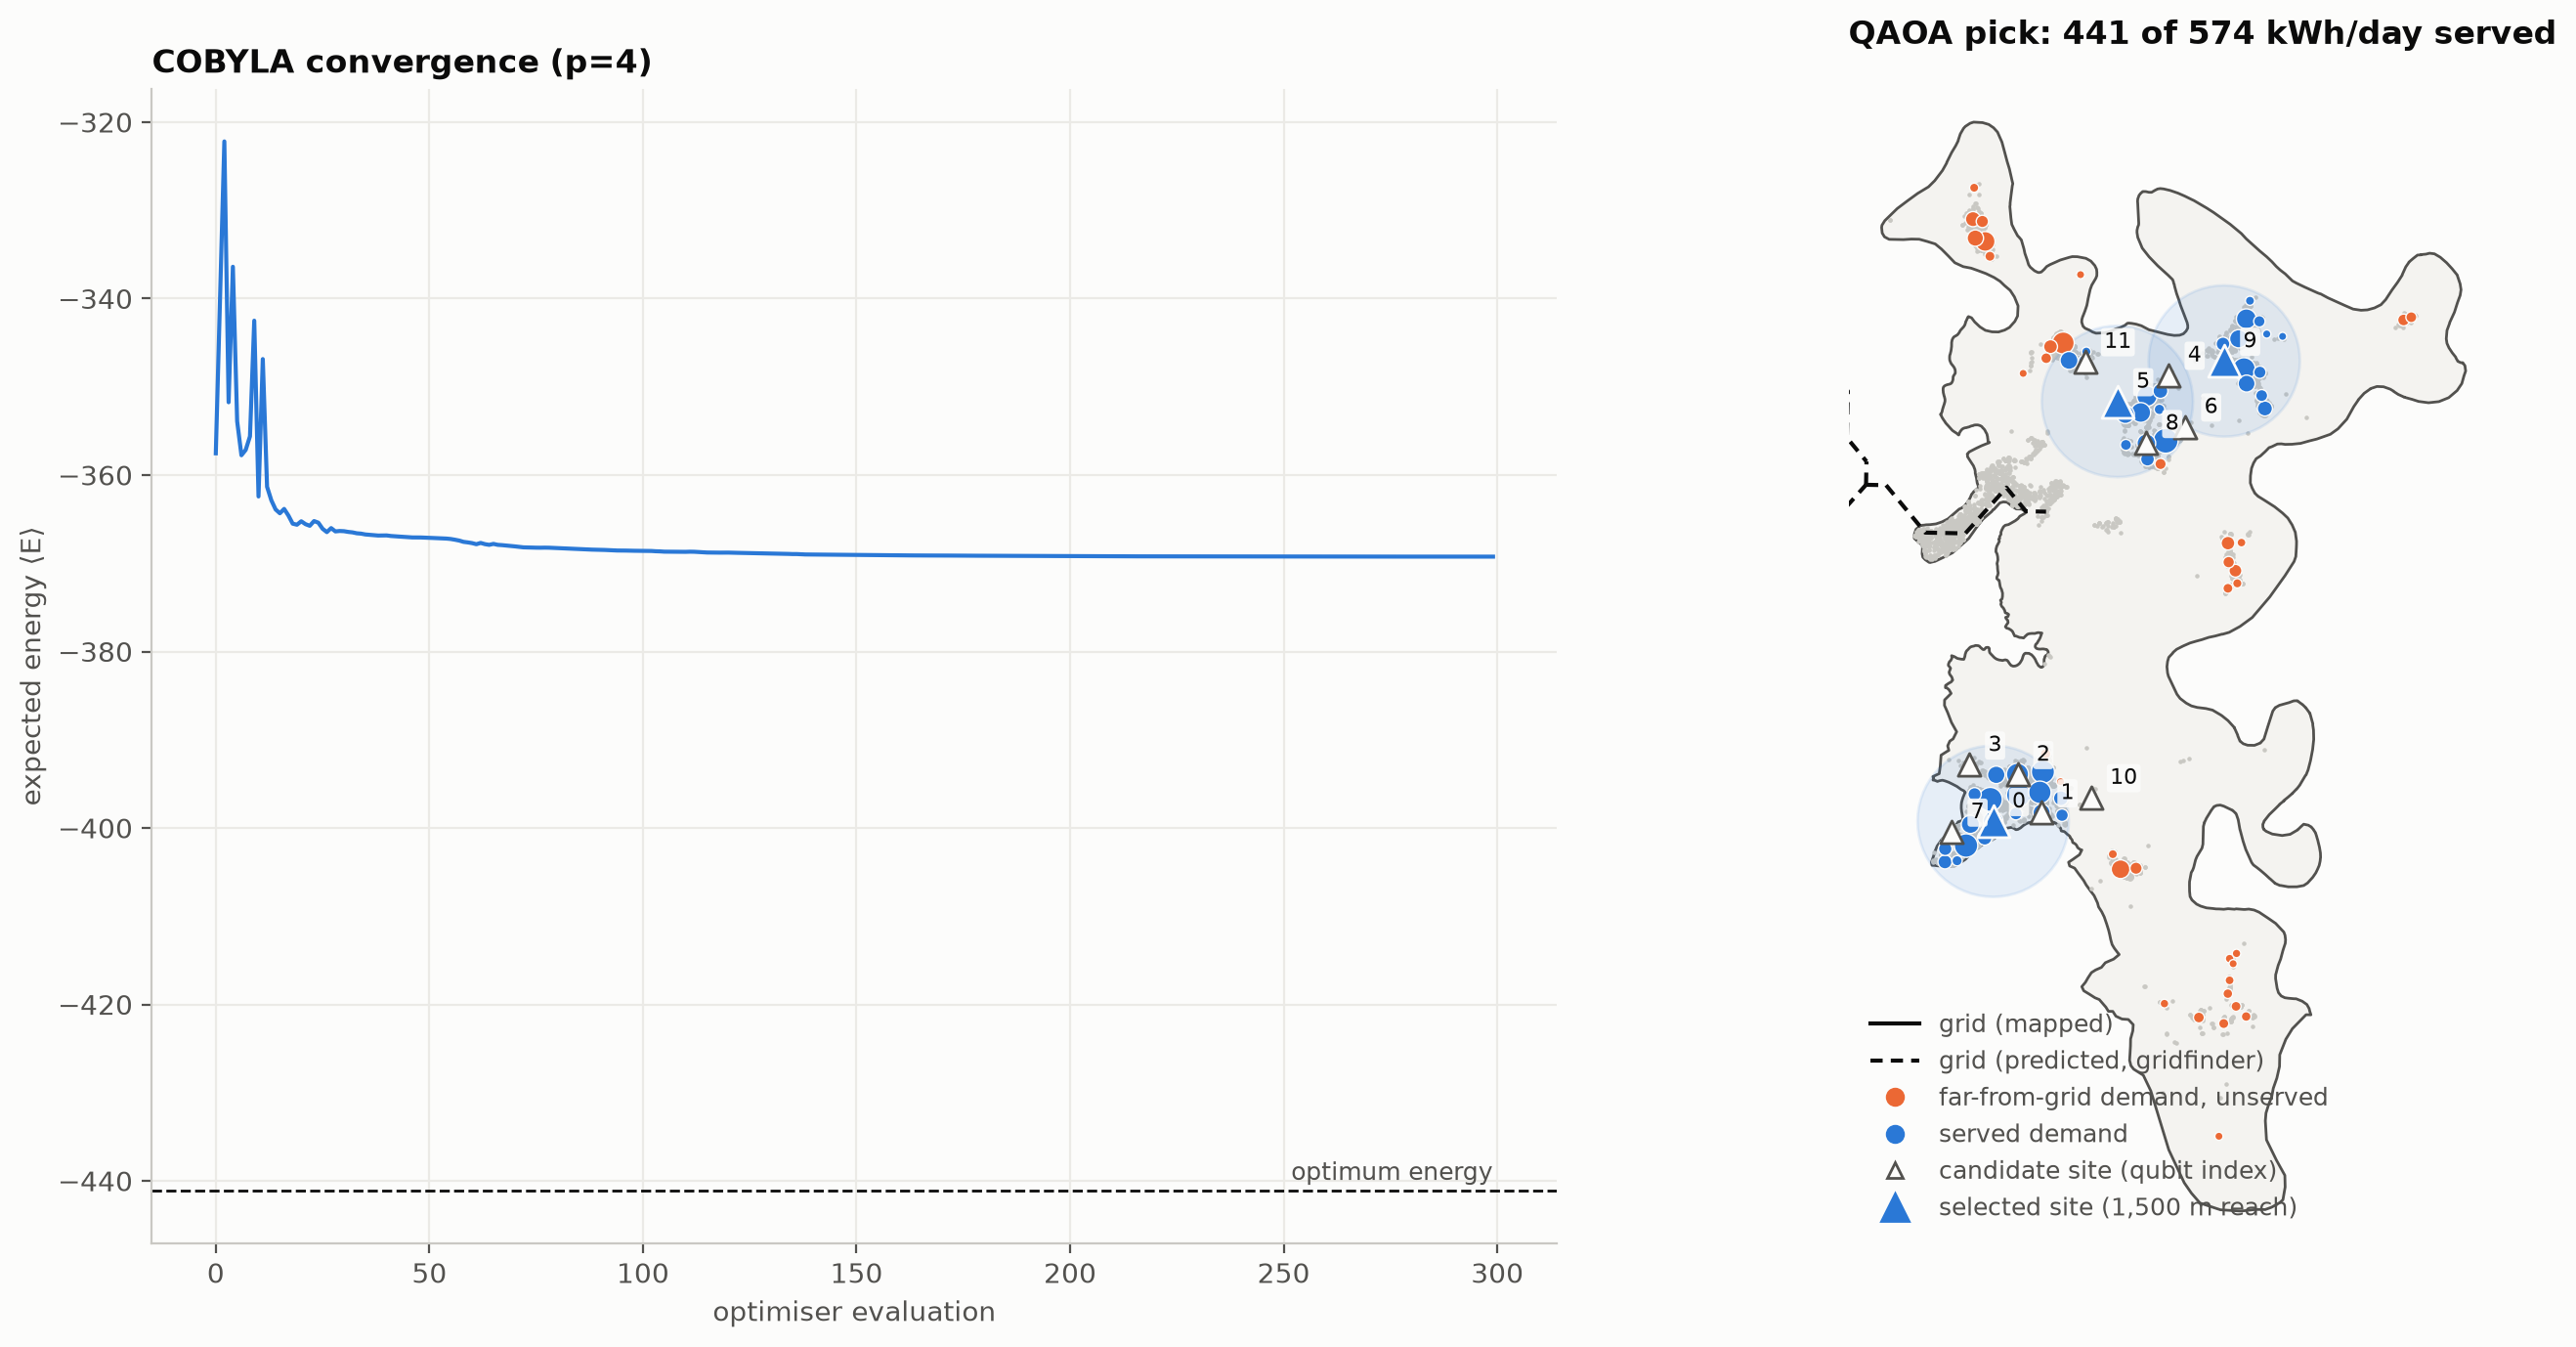

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.3]})
viz.plot_convergence(best, ax=axes[0])
viz.plot_pilot(pilot, best.x, ax=axes[1],
               title=f"QAOA pick: {p.served_demand(best.x):.0f} of {p.demand.sum():.0f} kWh/day served")
plt.tight_layout()
plt.show()

**Smaller instance.** Simulation cost doubles with each qubit. To decrease the cost,
decrease `n_candidates`. The 8-qubit instance is the input for the hardware run in section 7.
On this instance, depth 1 is below the random baseline. Depth 2 or more is necessary to do
better than a random selection.

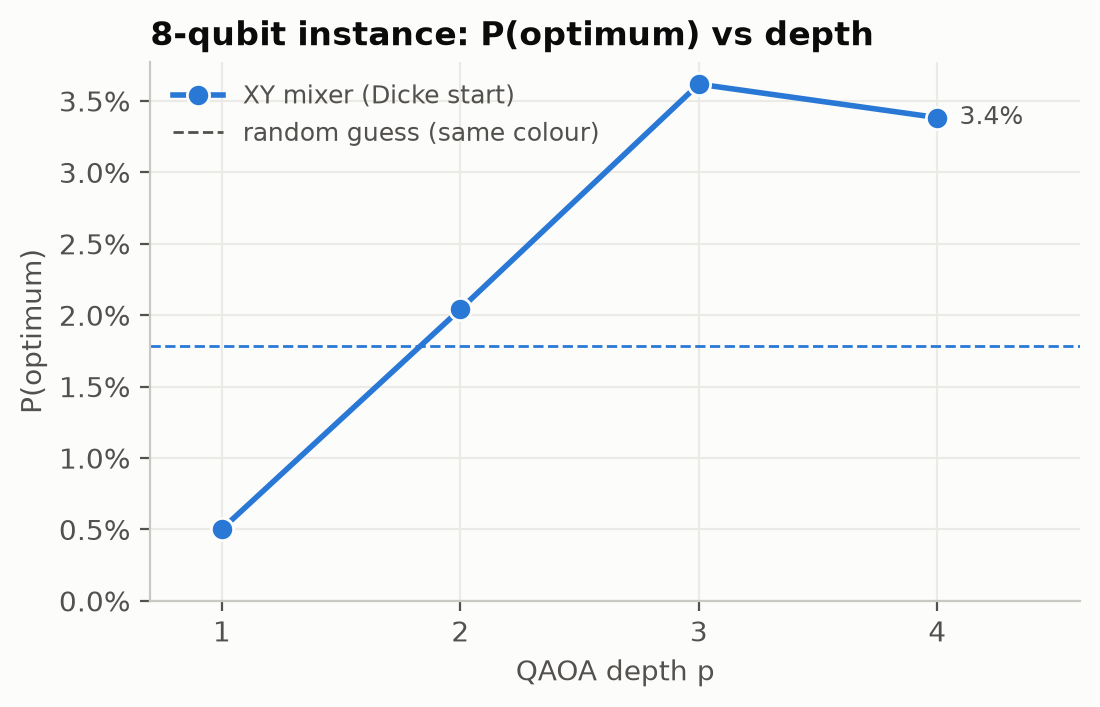

In [16]:
small = build_pilot(replace(cfg, n_candidates=8)).problem
small_sweep = {"xy": qaoa_depth_sweep(small, MAX_REPS, mixer="xy")}
viz.plot_depth_sweep(small_sweep, "p_ground")
plt.title("8-qubit instance: P(optimum) vs depth", loc="left")
plt.show()

## 7. IBM Quantum hardware

**Limitation.** Current quantum hardware limits the solution. Noise increases with circuit
size, so only the 8-qubit instance at depth 1 runs on the device. At this depth the ideal
circuit is already below the random baseline. Noise decreases the share of valid samples.
The best valid sample can still be the optimum, but only because each sample is checked
classically. The 12-qubit problem has no reliable hardware solution. The exact classical
solution remains the reference.

The simulator tunes the angles. The device only samples the tuned circuit.
`BACKEND = "fake_torino"` is a local simulation with the calibrated noise model of IBM Torino.
It does not need an account. To send a job to a device, set `BACKEND` to `"least_busy"` or a
device name, for example `"ibm_torino"`. The README gives the authentication steps.

In [17]:
from quackathon.hardware import run_on_backend
from quackathon.quantum import solve_qaoa

BACKEND = "fake_torino"
small_qaoa = solve_qaoa(small, reps=1)
hw = run_on_backend(small, small_qaoa, BACKEND, shots=4096)
print(f"{hw.backend}: {hw.two_qubit_gates} two-qubit gates, depth {hw.depth}")
print(f"  ideal simulator: P(optimum)={small_qaoa.p_ground:.3f}  P(feasible)={small_qaoa.p_feasible:.2f}")
print(f"  {hw.backend:15s}: P(optimum)={hw.p_ground:.3f}  P(feasible)={hw.p_feasible:.2f}  "
      f"(random valid plan {small_qaoa.p_ground_random:.3f})")
print(f"  best valid sample serves {small.served_demand(hw.x):.0f} kWh/day (optimum {small.served_demand(solve_exact(small).x):.0f})")

Submitted job 0953182b-6e45-4769-84f7-3a4279f50f07 to fake_torino; waiting for results...


fake_torino: 275 two-qubit gates, depth 683
  ideal simulator: P(optimum)=0.005  P(feasible)=1.00
  fake_torino    : P(optimum)=0.006  P(feasible)=0.45  (random valid plan 0.018)
  best valid sample serves 382 kWh/day (optimum 382)
